In [478]:
# Reload and test the saved model
reloaded_model = joblib.load(model_file_path)

sample_input = (X_test.head(5).copy())
sample_predictions = (reloaded_model.predict(sample_input))

model_validation_df = pd.DataFrame({
    "Actual Delivery Time": (y_test.head(5).values),
    "Reloaded Model Prediction": (sample_predictions)
})

print("Saved model reloaded successfully")
print("Model validation sample:")

display(model_validation_df.round(3))

print("\nFinal project locations:")
print("Project folder:", project_path)
print("Dataset:", data_path)
print("Reports:", results_path)
print("Model:", model_file_path)

Saved model reloaded successfully
Model validation sample:


,Actual Delivery Time,Reloaded Model Prediction
0,32,35.651
1,68,61.268
2,39,44.543
3,44,43.800
4,85,80.639



Final project locations:
Project folder: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project
Dataset: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\data\Food_Delivery_Times.csv
Reports: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results
Model: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\models\food_delivery_model.pkl


In [479]:
# Save and display the generated report file
generated_files = sorted(
    file_path
    for file_path
    in results_path.iterdir()
    if (
        file_path.is_file()
        and file_path.name
        != "generated_report_files.csv"
    )
)

generated_files_df = pd.DataFrame({
    "File Name": [
        file_path.name
        for file_path in generated_files
    ],

    "File Type": [
        file_path.suffix
        .replace(".", "")
        .upper()
        for file_path in generated_files
    ],

    "Size (KB)": [
        round(
            file_path.stat().st_size
            / 1024,
            2
        )
        for file_path in generated_files
    ]
})

generated_files_path = (results_path / "generated_report_files.csv")
generated_files_df.to_csv(generated_files_path, index=False)

print(
    "Generated report files "
    "excluding the inventory:",
    len(generated_files_df)
)
print(
    "File saved:",
    generated_files_path
)

display(generated_files_df)

Generated report files excluding the inventory: 39
File saved: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\generated_report_files.csv


,File Name,File Type,Size (KB)
0,figure01_delivery_time_distribution.png,PNG,58.82
1,figure02_average_delivery_time_by_traffic.png,PNG,49.37
2,figure03_average_delivery_time_by_weather.png,PNG,62.59
3,figure04_numerical_relationships_heatmap.png,PNG,108.18
4,figure05_cross_validation_mae_comparison.png,PNG,89.12
5,figure06_cross_validation_mae_rmse.png,PNG,86.33
6,figure07_actual_vs_predicted_delivery_time.png,PNG,163.65
7,figure08_selected_model_residual_distribution.png,PNG,66.19
8,figure09_permutation_feature_importance.png,PNG,70.56
9,table01_sample_dataset_records.csv,CSV,0.57


In [480]:
# Save summaries
if selected_parameters:
    selected_parameters_text = str(selected_parameters)
else:
    selected_parameters_text = "Default model parameters"

training_output_lines = [
    (
        "FOOD DELIVERY TIME PREDICTION "
        "- TRAINING OUTPUT"
    ),
    "=" * 70,

    f"Dataset path: {data_path}",
    f"Dataset shape: {df.shape}",
    f"Modelling records: {len(df_model)}",
    f"Training records: {len(X_train)}",
    f"Test records: {len(X_test)}",

    "",

    (
        "MODEL COMPARISON USING "
        "TRAINING CROSS-VALIDATION"
    ),
    "-" * 70,
    (
        model_results_df
        .round(3)
        .to_string(index=False)
    ),
    "",
    "SELECTED MODEL",
    "-" * 70,
    f"Model: {selected_model_name}",
    (
        "Selection rule: Lowest five-fold "
        "cross-validation MAE"
    ),
    f"Best parameters: {selected_parameters_text}",
    (
        f"CV MAE: "
        f"{selected_cv_metrics['CV MAE']:.3f} "
        f"minutes"
    ),
    (
        f"CV RMSE: "
        f"{selected_cv_metrics['CV RMSE']:.3f} "
        f"minutes"
    ),
    (
        f"CV R2: "
        f"{selected_cv_metrics['CV R2']:.3f}"
    ),
    "",
    "FINAL TEST PERFORMANCE",
    "-" * 70,

    f"Test MAE: {test_mae:.3f} minutes",
    f"Test RMSE: {test_rmse:.3f} minutes",
    f"Test R2: {test_r2:.3f}",

    "",

    f"Saved model: {model_file_path}"
]

training_output_text = "\n".join(training_output_lines)

training_output_path = (results_path / "training_output.txt")

training_output_path.write_text(
    training_output_text,
    encoding="utf-8"
)

training_summary = {
    "dataset_path": str(data_path),
    "dataset_shape": [
        int(df.shape[0]),
        int(df.shape[1])
    ],
    "modelling_records": int(
        len(df_model)
    ),
    "training_records": int(
        len(X_train)
    ),
    "test_records": int(
        len(X_test)
    ),
    "model_selection_rule": (
        "Lowest five-fold cross-validation "
        "MAE using training data only"
    ),
    "selected_model": (
        selected_model_name
    ),
    "selected_parameters": (
        selected_parameters
    ),
    "selected_cross_validation_metrics": {
        "CV MAE": float(
            selected_cv_metrics["CV MAE"]
        ),
        "CV RMSE": float(
            selected_cv_metrics["CV RMSE"]
        ),
        "CV R2": float(
            selected_cv_metrics["CV R2"]
        )
    },
    "final_test_metrics": {
        "Test MAE": float(test_mae),
        "Test RMSE": float(test_rmse),
        "Test R2": float(test_r2)
    },
    "all_model_cross_validation_metrics": (
        model_results_df
        .round(6)
        .to_dict(orient="records")
    ),
    "saved_model": str(
        model_file_path
    )
}

training_summary_path = (results_path / "training_summary.json")

with open(
    training_summary_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        training_summary,
        file,
        indent=4,
        default=float
    )

print(training_output_text)
print("\nSaved:", training_output_path)
print("Saved:", training_summary_path)

FOOD DELIVERY TIME PREDICTION - TRAINING OUTPUT
Dataset path: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\data\Food_Delivery_Times.csv
Dataset shape: (1000, 9)
Modelling records: 1000
Training records: 800
Test records: 200

MODEL COMPARISON USING TRAINING CROSS-VALIDATION
----------------------------------------------------------------------
 CV MAE Rank             Model  CV MAE  CV MAE Std  CV RMSE  CV RMSE Std  CV R2  Training R2                                               Best Parameters
           1 Linear Regression   6.808       0.405   11.058        0.666  0.749        0.763                                                            {}
           2  Ridge Regression   6.808       0.405   11.058        0.666  0.750        0.763                                                {"alpha": 0.1}
           3 Gradient Boosting   7.308       0.509   11.551        0.946  0.726        0.809   {"learning_rate": 0.1, "max_depth": 2, "n_estima

In [481]:
# Save the selected model
model_file_path = (models_path / "food_delivery_model.pkl")

joblib.dump(selected_model, model_file_path)

print("Selected model:", selected_model_name)
print("Saved model:", model_file_path)
print("Model file exists:", model_file_path.exists())

Selected model: Linear Regression
Saved model: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\models\food_delivery_model.pkl
Model file exists: True


Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table14_permutation_feature_importance.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table14_permutation_feature_importance.png
Saved figure: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\figure09_permutation_feature_importance.png


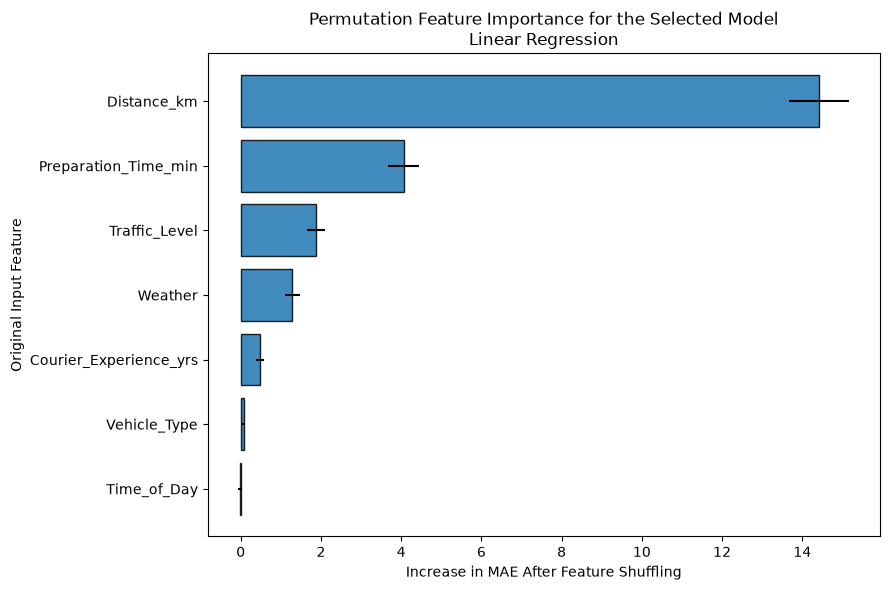

,Importance Rank,Feature,Mean Importance,Importance Standard Deviation
0,1,Distance_km,14.4226,0.7517
1,2,Preparation_Time_min,4.0611,0.3858
2,3,Traffic_Level,1.8817,0.2190
3,4,Weather,1.2889,0.1794
4,5,Courier_Experience_yrs,0.4769,0.0953
5,6,Vehicle_Type,0.0702,0.0319
6,7,Time_of_Day,-0.0210,0.0426


In [482]:
# Calculate and save permutation feature importance
importance_result = permutation_importance(
    estimator=selected_model,
    X=X_test,
    y=y_test,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=1
)

feature_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Importance": (
        importance_result.importances_mean
    ),
    "Importance Standard Deviation": (
        importance_result.importances_std
    )
})

feature_importance_df = (
    feature_importance_df
    .sort_values(by="Mean Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.insert(
    0,
    "Importance Rank",
    np.arange(1, len(feature_importance_df) + 1)
)

save_table_files(
    feature_importance_df,
    "table14_permutation_feature_importance",
    (
        "Permutation Feature Importance - "
        f"{selected_model_name}"
    )
)

importance_plot_df = (
    feature_importance_df
    .sort_values(by="Mean Importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    importance_plot_df["Feature"],
    importance_plot_df["Mean Importance"],
    xerr=importance_plot_df["Importance Standard Deviation"],
    edgecolor="black",
    alpha=0.85
)

plt.title(
    f"Permutation Feature Importance "
    f"for the Selected Model\n"
    f"{selected_model_name}"
)

plt.xlabel("Increase in MAE After Feature Shuffling")
plt.ylabel("Original Input Feature")
save_figure("figure09_permutation_feature_importance.png")

plt.show()
plt.close()

display(feature_importance_df.round(4))

Saved figure: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\figure08_selected_model_residual_distribution.png


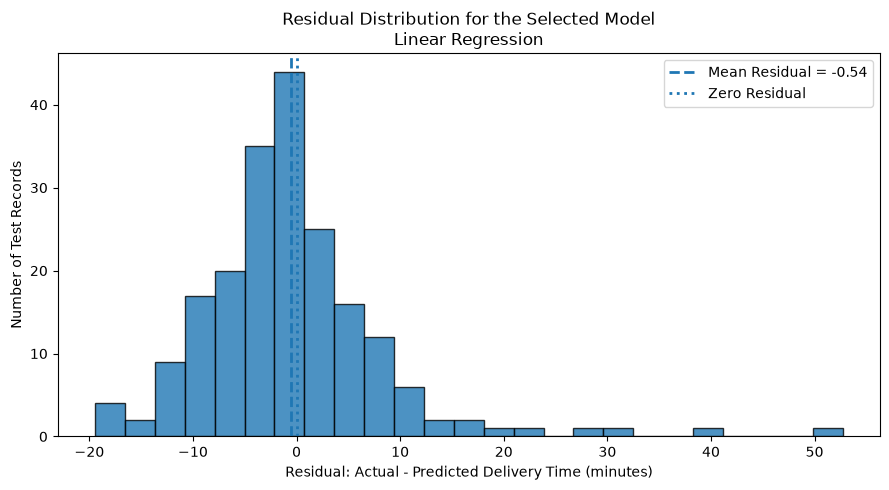

Mean residual: -0.5411047481222515
Residual standard deviation: 8.935802390773523


In [483]:
# Create the residual-distribution graph
residuals = (actual_values - selected_predictions)

plt.figure(figsize=(9, 5))

plt.hist(
    residuals,
    bins=25,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    residuals.mean(),
    linestyle="--",
    linewidth=2,
    label=(
        f"Mean Residual = "
        f"{residuals.mean():.2f}"
    )
)

plt.axvline(
    0,
    linestyle=":",
    linewidth=2,
    label="Zero Residual"
)

plt.title(
    f"Residual Distribution for the Selected Model\n"
    f"{selected_model_name}"
)

plt.xlabel(
    "Residual: Actual - Predicted "
    "Delivery Time (minutes)"
)

plt.ylabel("Number of Test Records")
plt.legend()

save_figure("figure08_selected_model_residual_distribution.png")

plt.show()
plt.close()

print("Mean residual:", residuals.mean())
print("Residual standard deviation:", residuals.std())

Saved figure: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\figure07_actual_vs_predicted_delivery_time.png


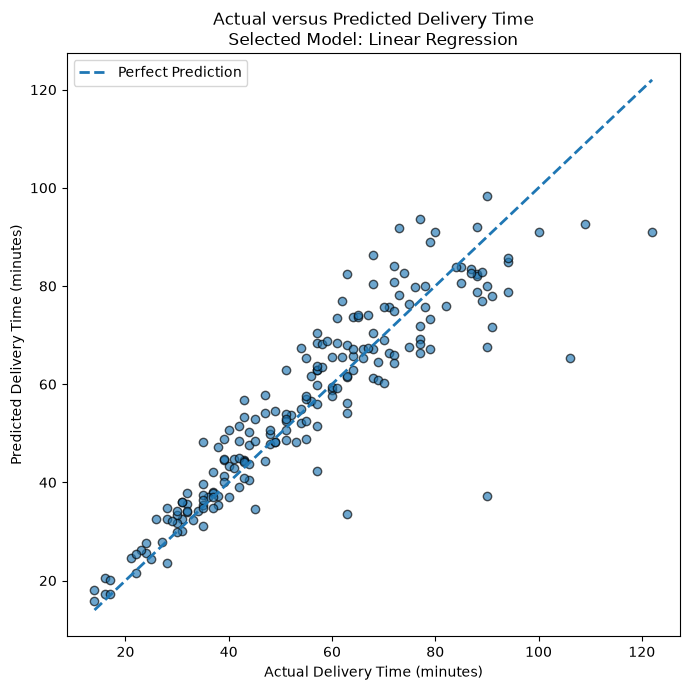

In [484]:
# Create the actual-versus-predicted graph
actual_values = y_test.values

minimum_value = min(actual_values.min(), selected_predictions.min())
maximum_value = max(actual_values.max(), selected_predictions.max())

plt.figure(figsize=(7, 7))

plt.scatter(
    actual_values,
    selected_predictions,
    alpha=0.65,
    edgecolor="black"
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    f"Actual versus Predicted Delivery Time\n"
    f"Selected Model: {selected_model_name}"
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")

plt.legend()

save_figure("figure07_actual_vs_predicted_delivery_time.png")

plt.show()
plt.close()

In [485]:
# Evaluate the selected model once on the test set
selected_predictions = (selected_model.predict(X_test))

test_mae = mean_absolute_error(y_test, selected_predictions)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        selected_predictions
    )
)

test_r2 = r2_score(y_test, selected_predictions)

final_test_metrics_df = pd.DataFrame({
    "Selected Model": [selected_model_name],
    "Test MAE": [test_mae],
    "Test RMSE": [test_rmse],
    "Test R2": [test_r2]
})

save_table_files(
    final_test_metrics_df,
    "table12_selected_model_test_metrics",
    "Final Test Performance of the Selected Model"
)

prediction_results_df = pd.DataFrame({
    "Order ID": df_model.loc[y_test.index, "Order_ID"].values,
    "Actual Delivery Time": (y_test.values),
    "Predicted Delivery Time": (selected_predictions)
})

prediction_results_df[
    "Residual"
] = (
    prediction_results_df["Actual Delivery Time"] 
    - prediction_results_df["Predicted Delivery Time"]
)

prediction_results_df[
    "Absolute Error"
] = (prediction_results_df["Residual"].abs())

save_table_files(
    prediction_results_df,
    "table13_selected_model_predictions",
    (
        "Actual and Predicted Delivery Times - "
        f"{selected_model_name}"
    )
)

display(final_test_metrics_df.round(3))

display(prediction_results_df.head(20).round(3))

Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table12_selected_model_test_metrics.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table12_selected_model_test_metrics.png
Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table13_selected_model_predictions.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table13_selected_model_predictions.png


,Selected Model,Test MAE,Test RMSE,Test R2
0,Linear Regression,6.063,8.952,0.821


,Order ID,Actual Delivery Time,Predicted Delivery Time,Residual,Absolute Error
0,667,32,35.651,-3.651,3.651
1,130,68,61.268,6.732,6.732
2,785,39,44.543,-5.543,5.543
3,153,44,43.800,0.200,0.200
4,921,85,80.639,4.361,4.361
5,946,31,32.600,-1.600,1.600
6,49,77,69.208,7.792,7.792
7,16,33,32.364,0.636,0.636
8,773,90,37.294,52.706,52.706
9,121,91,77.910,13.090,13.090


In [486]:
# Select the best model using cross-validation only
selected_model_name = (model_results_df.iloc[0]["Model"])

selected_grid_search = (grid_search_results[selected_model_name])

selected_model = (selected_grid_search.best_estimator_)

selected_parameters = (best_parameters_by_model[selected_model_name])

selected_cv_metrics = (model_results_df.iloc[0].to_dict())

print("Selected model:", selected_model_name)

print("Selection rule:", "Lowest five-fold cross-validation MAE")

print("Selected parameters:", selected_parameters)

print(
    "Selected model CV MAE:",
    f"{selected_cv_metrics['CV MAE']:.3f} minutes"
)

Selected model: Linear Regression
Selection rule: Lowest five-fold cross-validation MAE
Selected parameters: {}
Selected model CV MAE: 6.808 minutes


Saved figure: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\figure05_cross_validation_mae_comparison.png


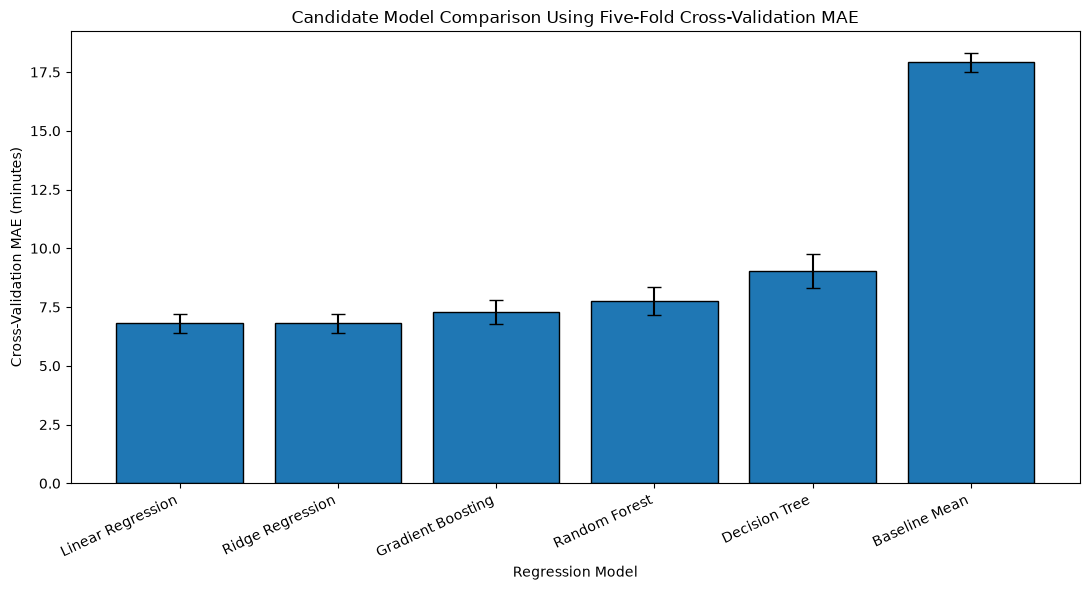

Saved figure: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\figure06_cross_validation_mae_rmse.png


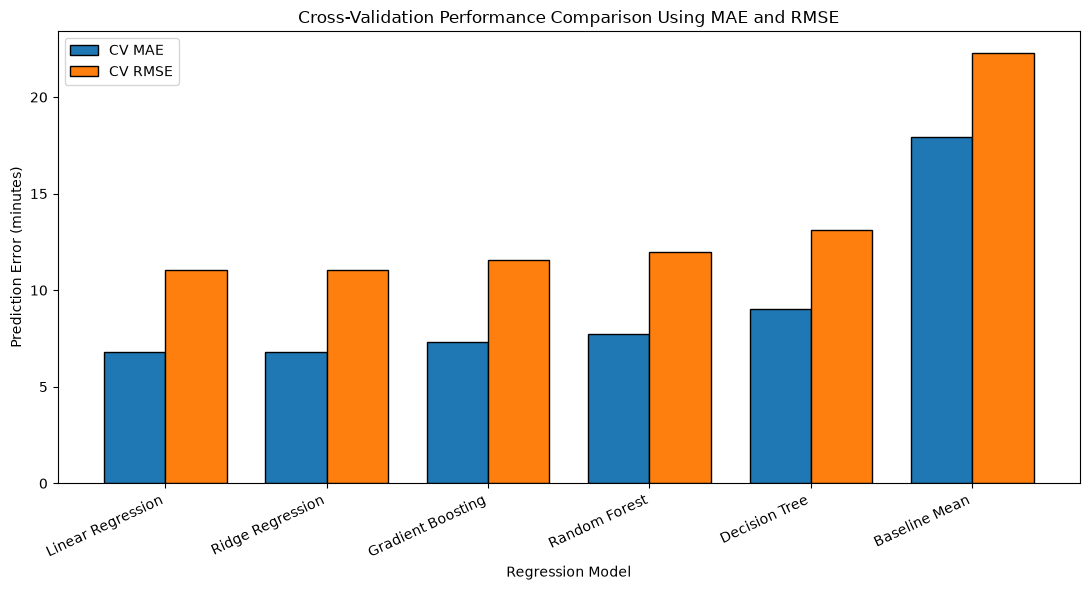

In [487]:
# Create cross-validation comparison graphs
comparison_df = model_results_df.sort_values(by="CV MAE")

positions = np.arange(len(comparison_df))

plt.figure(figsize=(11, 6))

plt.bar(
    positions,
    comparison_df["CV MAE"],
    yerr=comparison_df["CV MAE Std"],
    capsize=5,
    edgecolor="black"
)

plt.xticks(
    positions,
    comparison_df["Model"],
    rotation=25,
    ha="right"
)

plt.title(
    "Candidate Model Comparison Using "
    "Five-Fold Cross-Validation MAE"
)

plt.xlabel("Regression Model")
plt.ylabel("Cross-Validation MAE (minutes)")

save_figure("figure05_cross_validation_mae_comparison.png")

plt.show()
plt.close()

bar_width = 0.38

plt.figure(figsize=(11, 6))

plt.bar(
    positions - bar_width / 2,
    comparison_df["CV MAE"],
    width=bar_width,
    label="CV MAE",
    edgecolor="black"
)

plt.bar(
    positions + bar_width / 2,
    comparison_df["CV RMSE"],
    width=bar_width,
    label="CV RMSE",
    edgecolor="black"
)

plt.xticks(
    positions,
    comparison_df["Model"],
    rotation=25,
    ha="right"
)

plt.title(
    "Cross-Validation Performance Comparison "
    "Using MAE and RMSE"
)

plt.xlabel("Regression Model")
plt.ylabel("Prediction Error (minutes)")
plt.legend()

save_figure("figure06_cross_validation_mae_rmse.png")

plt.show()
plt.close()

In [488]:
# Save cross-validation model-comparison results
model_results_df = pd.DataFrame(
    model_evaluation_results
).sort_values(
    by=[
        "CV MAE",
        "CV RMSE"
    ]
).reset_index(drop=True)

model_results_df.insert(
    0,
    "CV MAE Rank",
    np.arange(1, len(model_results_df) + 1)
)

cross_validation_results_df = pd.DataFrame(cross_validation_fold_results)

save_table_files(
    model_results_df,
    "table10_model_comparison_cross_validation",
    "Model Comparison Using Training Cross-Validation"
)

save_table_files(
    cross_validation_results_df,
    "table11_cross_validation_fold_results",
    "Five-Fold Cross-Validation Results",
    max_rows=30
)

display(model_results_df.round(3))

Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table10_model_comparison_cross_validation.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table10_model_comparison_cross_validation.png
Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table11_cross_validation_fold_results.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table11_cross_validation_fold_results.png


,CV MAE Rank,Model,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,Training R2,Best Parameters
0,1,Linear Regression,6.808,0.405,11.058,0.666,0.749,0.763,{}
1,2,Ridge Regression,6.808,0.405,11.058,0.666,0.750,0.763,"{""alpha"": 0.1}"
2,3,Gradient Boosting,7.308,0.509,11.551,0.946,0.726,0.809,"{""learning_rate"": 0.1, ""max_depth"": 2, ""n_esti..."
3,4,Random Forest,7.752,0.594,11.972,0.941,0.705,0.914,"{""max_depth"": 12, ""min_samples_leaf"": 2, ""n_es..."
4,5,Decision Tree,9.044,0.713,13.139,1.161,0.645,0.762,"{""max_depth"": 5, ""min_samples_leaf"": 4}"
5,6,Baseline Mean,17.920,0.397,22.290,0.795,-0.010,0.000,{}


In [489]:
# Tune and cross-validate all candidate models
model_evaluation_results = []
cross_validation_fold_results = []
grid_search_results = {}
best_parameters_by_model = {}

for model_name, model in models.items():
    print("\nTuning and evaluating:", model_name)

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", clone(model))
        ]
    )

    grid_search = GridSearchCV(
        estimator=model_pipeline,
        param_grid=parameter_grids[model_name],
        scoring=scoring,
        refit="MAE",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)
    best_index = (grid_search.best_index_)
    cv_results = (grid_search.cv_results_)

    best_parameters = {
        key.replace(
            "model__",
            ""
        ): value

        for key, value
        in grid_search.best_params_.items()
    }

    best_parameters_by_model[
        model_name
    ] = best_parameters

    model_evaluation_results.append({
        "Model": model_name,
        "CV MAE": -cv_results["mean_test_MAE"][best_index],
        "CV MAE Std": cv_results["std_test_MAE"][best_index],
        "CV RMSE": -cv_results["mean_test_RMSE"][best_index],
        "CV RMSE Std": cv_results["std_test_RMSE"][best_index],
        "CV R2": cv_results["mean_test_R2"][best_index],
        "Training R2": cv_results["mean_train_R2"][best_index],
        "Best Parameters": json.dumps(best_parameters)
    })

    for fold_number in range(
        cv.get_n_splits()
    ):

        cross_validation_fold_results.append({
            "Model": model_name,
            "Fold": fold_number + 1,
            "Validation MAE": -cv_results[
                f"split{fold_number}_test_MAE"
            ][best_index],
            "Validation RMSE": -cv_results[
                f"split{fold_number}_test_RMSE"
            ][best_index],
            "Validation R2": cv_results[
                f"split{fold_number}_test_R2"
            ][best_index],
            "Training R2": cv_results[
                f"split{fold_number}_train_R2"
            ][best_index]
        })

    grid_search_results[
        model_name
    ] = grid_search

    print("Best parameters:", best_parameters)
    print("Best CV MAE:", -grid_search.best_score_)

print(
    "\nAll candidate models were evaluated"
)


Tuning and evaluating: Baseline Mean
Best parameters: {}
Best CV MAE: 17.920046875

Tuning and evaluating: Linear Regression
Best parameters: {}
Best CV MAE: 6.80752672604893

Tuning and evaluating: Ridge Regression
Best parameters: {'alpha': 0.1}
Best CV MAE: 6.807650447801983

Tuning and evaluating: Decision Tree
Best parameters: {'max_depth': 5, 'min_samples_leaf': 4}
Best CV MAE: 9.043700093098167

Tuning and evaluating: Random Forest
Best parameters: {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 100}
Best CV MAE: 7.751770094251969

Tuning and evaluating: Gradient Boosting
Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
Best CV MAE: 7.3080517006905055

All candidate models were evaluated


In [490]:
# Configure cross-validation and evaluation metrics
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

print("Five-fold cross-validation configured successfully")

print(
    "Model-selection metric: "
    "lowest cross-validation MAE"
)

Five-fold cross-validation configured successfully
Model-selection metric: lowest cross-validation MAE


In [491]:
# Define candidate models and hyperparameter grids
models = {
    "Baseline Mean": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

parameter_grids = {
    "Baseline Mean": {},
    "Linear Regression": {},
    "Ridge Regression": {
        "model__alpha": [0.1, 1.0, 10.0]
    },
    "Decision Tree": {
        "model__max_depth": [5, 8],
        "model__min_samples_leaf": [2, 4]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [8, 12],
        "model__min_samples_leaf": [1, 2]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 150],
        "model__learning_rate": [0.05, 0.10],
        "model__max_depth": [2, 3]
    }
}

print("Candidate models and parameter grids created")

for model_name in models:
    print("-", model_name)

Candidate models and parameter grids created
- Baseline Mean
- Linear Regression
- Ridge Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [492]:
# Split the data and save the split summary
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

split_summary_df = pd.DataFrame({
    "Dataset Part": [
        "Complete Modelling Dataset",
        "Training Dataset",
        "Test Dataset"
    ],
    "Record Count": [
        len(X),
        len(X_train),
        len(X_test)
    ],
    "Percentage": [
        100.0,
        len(X_train) / len(X) * 100,
        len(X_test) / len(X) * 100
    ]
})

save_table_files(
    split_summary_df,
    "table09_train_test_split_summary",
    "Training and Test Data Split"
)

print("Training input shape:", X_train.shape)

print("Testing input shape:", X_test.shape)

display(split_summary_df.round(2))

Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table09_train_test_split_summary.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table09_train_test_split_summary.png
Training input shape: (800, 7)
Testing input shape: (200, 7)


,Dataset Part,Record Count,Percentage
0,Complete Modelling Dataset,1000,100.0
1,Training Dataset,800,80.0
2,Test Dataset,200,20.0


In [493]:
# Build the pre-processing pipeline
one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", one_hot_encoder)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully")

print(preprocessor)

Preprocessing pipeline created successfully
ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Distance_km', 'Preparation_Time_min',
                                  'Courier_Experience_yrs']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Weather', 'Traffic_Level', 'Time_of_Day',
                               

In [494]:
# Define the modelling features and target
target_column = "Delivery_Time_min"

numerical_features = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs"
]

categorical_features = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type"
]

model_features = (numerical_features + categorical_features)

df_model = df.dropna(subset=[target_column]).copy()

X = df_model[model_features].copy()

y = df_model[target_column].copy()

print("Records removed because the target was missing:", len(df) - len(df_model))

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Model features:", model_features)

Records removed because the target was missing: 0
Input shape: (1000, 7)
Target shape: (1000,)
Model features: ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']


Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table08_numerical_feature_correlations.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table08_numerical_feature_correlations.png
Saved figure: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\figure04_numerical_relationships_heatmap.png


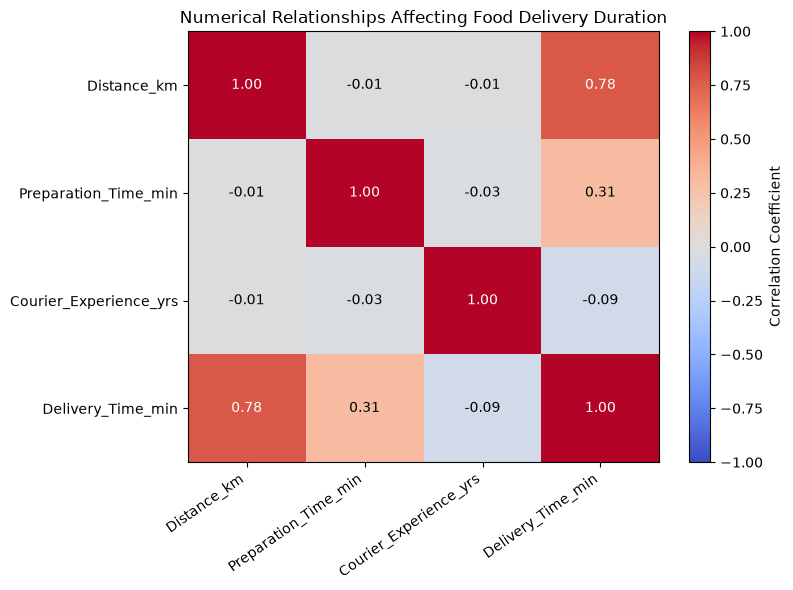

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
Distance_km,1.000,-0.009,-0.008,0.781
Preparation_Time_min,-0.009,1.000,-0.031,0.307
Courier_Experience_yrs,-0.008,-0.031,1.000,-0.090
Delivery_Time_min,0.781,0.307,-0.090,1.000


In [495]:
# Save correlation values and create the correlation heatmap
correlation_columns = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Delivery_Time_min"
]

correlation_df = (
    df[correlation_columns].corr()
)

correlation_table_df = (
    correlation_df
    .reset_index()
    .rename(columns={"index": "Feature"})
)

save_table_files(
    correlation_table_df,
    "table08_numerical_feature_correlations",
    "Numerical Feature Correlation Matrix"
)

plt.figure(figsize=(8, 6))

heatmap = plt.imshow(
    correlation_df,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(
    heatmap,
    label="Correlation Coefficient"
)

plt.xticks(
    np.arange(
        len(correlation_columns)
    ),
    correlation_columns,
    rotation=35,
    ha="right"
)

plt.yticks(
    np.arange(
        len(correlation_columns)
    ),
    correlation_columns
)

for row in range(
    len(correlation_columns)
):
    for column in range(
        len(correlation_columns)
    ):
        value = correlation_df.iloc[
            row,
            column
        ]

        plt.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=(
                "white"
                if abs(value) >= 0.60
                else "black"
            )
        )

plt.title(
    "Numerical Relationships Affecting "
    "Food Delivery Duration"
)

save_figure("figure04_numerical_relationships_heatmap.png")

plt.show()
plt.close()

display(correlation_df.round(3))

Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table07_delivery_time_by_weather.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table07_delivery_time_by_weather.png
Saved figure: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\figure03_average_delivery_time_by_weather.png


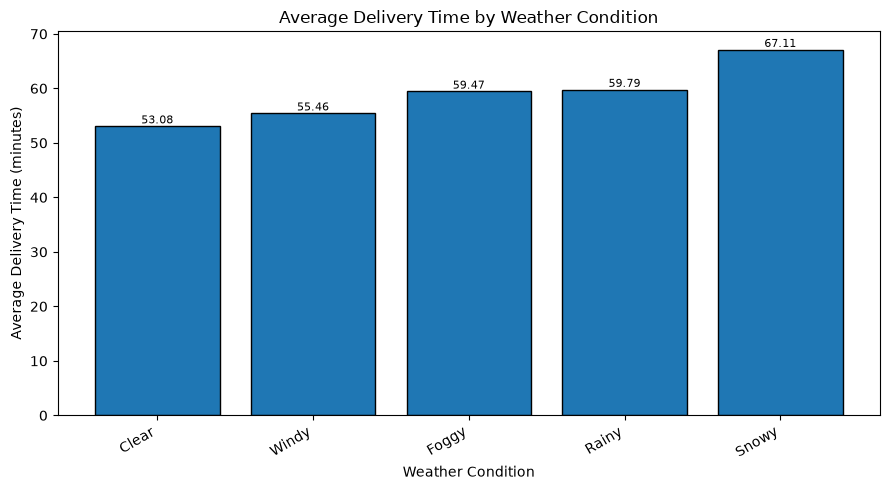

,Weather Condition,Order Count,Average Delivery Time,Median Delivery Time
0,Clear,470,53.083,52.0
1,Windy,96,55.458,55.0
2,Foggy,103,59.466,59.0
3,Rainy,204,59.794,57.5
4,Snowy,97,67.113,66.0


In [496]:
# Save weather summary and create the weather graph
weather_summary_df = (
    df.groupby(
        "Weather"
    )["Delivery_Time_min"]
    .agg(["count", "mean", "median"])
    .sort_values("mean")
    .reset_index()
)

weather_summary_df.columns = [
    "Weather Condition",
    "Order Count",
    "Average Delivery Time",
    "Median Delivery Time"
]

save_table_files(
    weather_summary_df,
    "table07_delivery_time_by_weather",
    "Average Delivery Time by Weather Condition"
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    weather_summary_df["Weather Condition"],
    weather_summary_df["Average Delivery Time"],
    edgecolor="black"
)

plt.title("Average Delivery Time by Weather Condition")

plt.xlabel("Weather Condition")
plt.ylabel("Average Delivery Time (minutes)")

plt.xticks(rotation=30, ha="right")

for bar, value in zip(
    bars,
    weather_summary_df[
        "Average Delivery Time"
    ]
):
    if pd.notna(value):
        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

save_figure("figure03_average_delivery_time_by_weather.png")

plt.show()
plt.close()

display(
    weather_summary_df.round(3)
)

Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table06_delivery_time_by_traffic.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table06_delivery_time_by_traffic.png
Saved figure: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\figure02_average_delivery_time_by_traffic.png


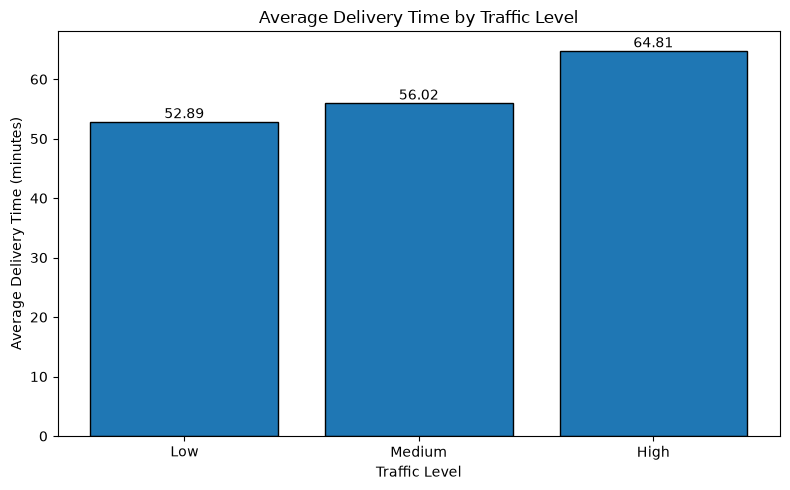

,Traffic Level,Order Count,Average Delivery Time,Median Delivery Time
0,Low,383,52.885,51.0
1,Medium,390,56.021,53.5
2,High,197,64.807,65.0


In [497]:
# Save traffic summary and create the traffic graph
traffic_order = ["Low", "Medium", "High"]

traffic_summary_df = (
    df.groupby("Traffic_Level")
    ["Delivery_Time_min"]
    .agg(["count", "mean", "median"])
    .reindex(traffic_order)
    .reset_index()
)

traffic_summary_df.columns = [
    "Traffic Level",
    "Order Count",
    "Average Delivery Time",
    "Median Delivery Time"
]

save_table_files(
    traffic_summary_df,
    "table06_delivery_time_by_traffic",
    "Average Delivery Time by Traffic Level"
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    traffic_summary_df["Traffic Level"],
    traffic_summary_df[
        "Average Delivery Time"
    ],
    edgecolor="black"
)

plt.title("Average Delivery Time by Traffic Level")

plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (minutes)")

for bar, value in zip(
    bars,
    traffic_summary_df[
        "Average Delivery Time"
    ]
):
    if pd.notna(value):
        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}",
            ha="center",
            va="bottom"
        )

save_figure(
    "figure02_average_delivery_time_by_traffic.png"
)

plt.show()
plt.close()

display(
    traffic_summary_df.round(3)
)

Saved figure: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\figure01_delivery_time_distribution.png


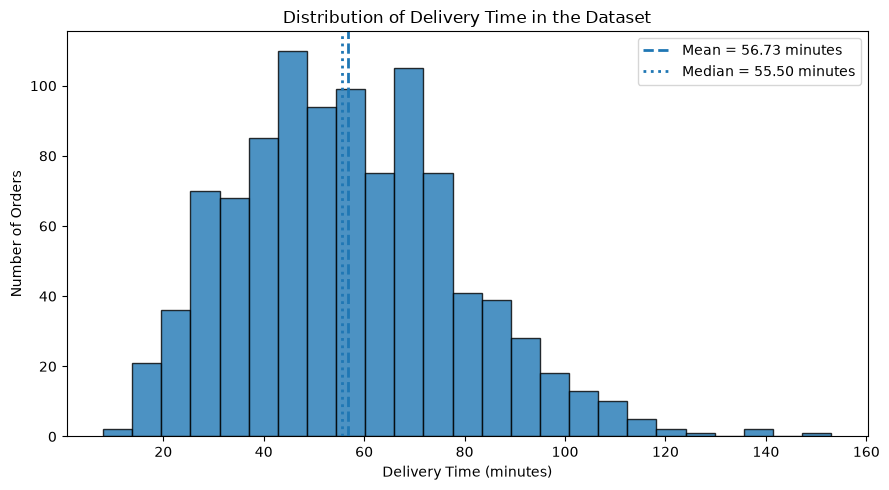

In [498]:
# Create the delivery-time distribution graph
delivery_time_values = (df["Delivery_Time_min"].dropna())

plt.figure(figsize=(9, 5))

plt.hist(
    delivery_time_values,
    bins=25,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    delivery_time_values.mean(),
    linestyle="--",
    linewidth=2,
    label=(
        f"Mean = "
        f"{delivery_time_values.mean():.2f} minutes"
    )
)

plt.axvline(
    delivery_time_values.median(),
    linestyle=":",
    linewidth=2,
    label=(
        f"Median = "
        f"{delivery_time_values.median():.2f} minutes"
    )
)

plt.title(
    "Distribution of Delivery Time in the Dataset"
)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.legend()

save_figure(
    "figure01_delivery_time_distribution.png"
)

plt.show()
plt.close()

In [499]:
# Create descriptive statistics
descriptive_statistics_df = (
    df.describe(include="all")
    .transpose()
    .reset_index()
    .rename(columns={"index": "Feature"})
)

save_table_files(
    descriptive_statistics_df,
    "table05_descriptive_statistics",
    "Descriptive Statistics of Dataset Features"
)

display(descriptive_statistics_df)

Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table05_descriptive_statistics.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table05_descriptive_statistics.png


,Feature,count,unique,top,freq,mean,std,min,25%,50%,75%,max
0,Order_ID,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
1,Distance_km,1000.0,NaN,NaN,NaN,10.05997,5.696656,0.59,5.105,10.19,15.0175,19.99
2,Weather,970,5,Clear,470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Traffic_Level,970,3,Medium,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Time_of_Day,970,4,Morning,308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Vehicle_Type,1000,3,Bike,503,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Preparation_Time_min,1000.0,NaN,NaN,NaN,16.982,7.204553,5.0,11.0,17.0,23.0,29.0
7,Courier_Experience_yrs,970.0,NaN,NaN,NaN,4.579381,2.914394,0.0,2.0,5.0,7.0,9.0
8,Delivery_Time_min,1000.0,NaN,NaN,NaN,56.732,22.070915,8.0,41.0,55.5,71.0,153.0


In [500]:
# Perform data quality and validity checks
data_quality_checks = [
    {
        "Check": "Duplicate complete records",
        "Count": int(df.duplicated().sum())
    },
    {
        "Check": "Duplicate Order_ID values",
        "Count": int(df["Order_ID"].duplicated().sum())
    },
    {
        "Check": "Negative Distance_km values",
        "Count": int((df["Distance_km"].dropna() < 0).sum())
    },
    {
        "Check": "Negative Preparation_Time_min values",
        "Count": int((df["Preparation_Time_min"].dropna() < 0).sum())
    },
    {
        "Check": "Negative Courier_Experience_yrs values",
        "Count": int((df["Courier_Experience_yrs"].dropna() < 0).sum())
    },
    {
        "Check": "Non-positive Delivery_Time_min values",
        "Count": int((df["Delivery_Time_min"].dropna() <= 0).sum())
    }
]

data_quality_df = pd.DataFrame(data_quality_checks)

save_table_files(
    data_quality_df,
    "table04_data_quality_summary",
    "Data Quality and Validity Checks"
)

print("Weather categories:")
print(
    df["Weather"].value_counts(
        dropna=False
    )
)

print("\nTraffic-level categories:")
print(
    df["Traffic_Level"].value_counts(
        dropna=False
    )
)

print("\nTime-of-day categories:")
print(
    df["Time_of_Day"].value_counts(
        dropna=False
    )
)

print("\nVehicle-type categories:")
print(
    df["Vehicle_Type"].value_counts(
        dropna=False
    )
)

display(data_quality_df)

Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table04_data_quality_summary.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table04_data_quality_summary.png
Weather categories:
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64

Traffic-level categories:
Traffic_Level
Medium    390
Low       383
High      197
NaN        30
Name: count, dtype: int64

Time-of-day categories:
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
NaN           30
Name: count, dtype: int64

Vehicle-type categories:
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64


,Check,Count
0,Duplicate complete records,0
1,Duplicate Order_ID values,0
2,Negative Distance_km values,0
3,Negative Preparation_Time_min values,0
4,Negative Courier_Experience_yrs values,0
5,Non-positive Delivery_Time_min values,0


In [501]:
# Create the missing value summary
missing_values_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing Percentage": df.isnull().mean().values * 100
})

missing_values_df = missing_values_df.sort_values(
    by=["Missing Values", "Column"],
    ascending=[False, True]
).reset_index(drop=True)

save_table_files(
    missing_values_df,
    "table03_missing_value_summary",
    "Missing Value Summary"
)

display(missing_values_df.round(3))

Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table03_missing_value_summary.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table03_missing_value_summary.png


,Column,Missing Values,Missing Percentage
0,Courier_Experience_yrs,30,3.0
1,Time_of_Day,30,3.0
2,Traffic_Level,30,3.0
3,Weather,30,3.0
4,Delivery_Time_min,0,0.0
5,Distance_km,0,0.0
6,Order_ID,0,0.0
7,Preparation_Time_min,0,0.0
8,Vehicle_Type,0,0.0


In [502]:
# Save sample records and dataset structure
sample_records_df = df.head(10).copy()

save_table_files(
    sample_records_df,
    "table01_sample_dataset_records",
    "Sample Records from the Food Delivery Dataset",
    max_rows=10
)

dataset_structure_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.notnull().sum().values,
    "Missing Count": df.isnull().sum().values
})

save_table_files(
    dataset_structure_df,
    "table02_dataset_column_structure",
    "Dataset Column Structure"
)

display(sample_records_df)
display(dataset_structure_df)

Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table01_sample_dataset_records.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table01_sample_dataset_records.png
Saved table: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table02_dataset_column_structure.csv
Saved table preview: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results\table02_dataset_column_structure.png


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46
8,860,1.78,Snowy,Low,Evening,Car,20,6.0,35
9,137,10.62,Foggy,Low,Evening,Scooter,29,1.0,73


,Column,Data Type,Non-Null Count,Missing Count
0,Order_ID,int64,1000,0
1,Distance_km,float64,1000,0
2,Weather,str,970,30
3,Traffic_Level,str,970,30
4,Time_of_Day,str,970,30
5,Vehicle_Type,str,1000,0
6,Preparation_Time_min,int64,1000,0
7,Courier_Experience_yrs,float64,970,30
8,Delivery_Time_min,int64,1000,0


In [503]:
# Load and validate the dataset
df = pd.read_csv(data_path)

required_columns = [
    "Order_ID",
    "Distance_km",
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Delivery_Time_min"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The dataset is missing these required columns: "
        + ", ".join(missing_columns)
    )

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)
print("Dataset columns:", df.columns.tolist())

display(df.head())

Dataset loaded successfully
Dataset shape: (1000, 9)
Dataset columns: ['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [504]:
# Saving figures and tables
def save_figure(file_name):
    figure_path = results_path / file_name

    plt.tight_layout()

    plt.savefig(figure_path, dpi=200, bbox_inches="tight")

    print("Saved figure:", figure_path)


def save_table_files(dataframe, file_name, title, max_rows=20):
    csv_path = results_path / f"{file_name}.csv"
    png_path = results_path / f"{file_name}.png"

    dataframe.to_csv(csv_path, index=False)

    preview_df = dataframe.head(max_rows).copy()

    for column in preview_df.select_dtypes(include=np.number).columns:
        preview_df[column] = preview_df[column].round(3)

    preview_df = preview_df.astype(object)
    preview_df = preview_df.where(pd.notna(preview_df), "")

    row_count, column_count = preview_df.shape

    figure_width = max(10, min(24, column_count * 1.6))

    figure_height = max(3, min(16, (row_count + 2) * 0.55))

    fig, ax = plt.subplots(figsize=(figure_width, figure_height))

    ax.axis("off")

    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)

    table = ax.table(cellText=preview_df.astype(str).values, 
    colLabels=preview_df.columns.astype(str), cellLoc="center", loc="center")

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.3)

    fig.tight_layout()

    fig.savefig(png_path, dpi=200, bbox_inches="tight")

    plt.close(fig)

    print("Saved table:", csv_path)
    print("Saved table preview:", png_path)


print("Saving functions created successfully")

Saving functions created successfully


In [505]:
# Define portable project paths
current_path = Path.cwd().resolve()

if current_path.name.lower() == "notebooks":
    project_path = current_path.parent
else:
    project_path = current_path

data_path = project_path / "data" / "Food_Delivery_Times.csv"
results_path = project_path / "reports" / "results"
models_path = project_path / "models"

results_path.mkdir(parents=True, exist_ok=True)
models_path.mkdir(parents=True, exist_ok=True)

print("Current working directory:", current_path)
print("Project folder:", project_path)
print("Dataset path:", data_path)
print("Results folder:", results_path)
print("Models folder:", models_path)

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {data_path}\n"
        "Place Food_Delivery_Times.csv inside the data folder."
    )

Current working directory: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\notebooks
Project folder: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project
Dataset path: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\data\Food_Delivery_Times.csv
Results folder: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\reports\results
Models folder: C:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\models


In [506]:
# Import the required libraries
from pathlib import Path
import json

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

print("Libraries imported successfully")
print("pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("scikit-learn version:", sklearn.__version__)
print("joblib version:", joblib.__version__)

Libraries imported successfully
pandas version: 3.0.3
NumPy version: 2.5.1
Matplotlib version: 3.11.0
scikit-learn version: 1.9.0
joblib version: 1.5.3


In [507]:
# Python environment check
import sys

print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: c:\Users\krishantha.costa\Personal\Personal\MSc\MSc - AML\Assignment\food-delivery-project\.venv\Scripts\python.exe
Python version: 3.14.6 (tags/v3.14.6:c63aec6, Jun 10 2026, 10:26:10) [MSC v.1944 64 bit (AMD64)]
